# Two-Phase Bayesian Optimization — NYX & WarpX (combined 2×2 / 1×4)

Runs the joint **LR × slice-direction** two-phase BO pipeline on **both** datasets
and renders the combined figure:

|          | **Phase 1** (proxy BO) | **Phase 2** (full-res validation) |
|----------|------------------------|-----------------------------------|
| **NYX**  | top-left               | top-right                         |
| **WarpX**| bottom-left            | bottom-right                      |

Budgets: **NYX = 10 s**, **WarpX = 10 s**.  For each: **Phase 1 = 10 %** of the
budget, **Phase 2 = the remaining 90 %**, **10 trials** each.

NYX is a multifield 512³ volume (baryon_density target + 5 aux fields); WarpX is a
single-field volume stored as 256×256×2048 (float64), reoriented to (2048, 256, 256)
float32 so the 2-D slices are square 256×256 (SZ3 rel-err = 3e-2).

The shared `run_two_phase(...)` function runs the LR × slice-direction BO and returns
everything the combined plot needs.

In [1]:
import random, sys, os, copy, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")

from config_io import load_multifield_from_disk
# Force-reload edited modules so re-running picks up bg_stage.py changes WITHOUT
# restarting the kernel (Jupyter caches modules in sys.modules).
import importlib
import bg_stage
importlib.reload(bg_stage)

from experiment import build_bg_only_cfg
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
from bg_shard import pick_bg_h_under_budget

pysz_dir = "/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_dir not in sys.path:
    sys.path.append(pysz_dir)
from pysz import SZ

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda:0 | GPUs: 1


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Slice-direction permutations ──────────────────────────────────────────────
# Data layout: (Z, Y, X). Permute so the target slice axis becomes axis-0 (depth).
DIRECTIONS = ["Z", "Y", "X"]
_FWD = {"Z": (0, 1, 2), "Y": (1, 0, 2), "X": (2, 0, 1)}
_INV = {"Z": (0, 1, 2), "Y": (1, 0, 2), "X": (1, 2, 0)}
_DIR_AXIS = {"Z": 0, "Y": 1, "X": 2}


def permute_fields(fields, direction):
    axes = _FWD[direction]
    if axes == (0, 1, 2):
        return fields
    return [np.ascontiguousarray(np.transpose(f, axes)) for f in fields]


def unpermute_field(field, direction):
    axes = _INV[direction]
    if axes == (0, 1, 2):
        return field
    return np.ascontiguousarray(np.transpose(field, axes))


def build_cfg(Xs_in, Xps_in, max_train_time, bg_h, steps_per_epoch,
              lr=1e-4, epochs=200, log_prefix="", patch_size=None):
    if patch_size is None:
        patch_size = Xs_in[0].shape[2]
    cfg = build_bg_only_cfg(
        X_target=Xs_in[0], Xps=Xps_in,
        max_train_time=max_train_time, epochs=epochs,
        steps_per_epoch=steps_per_epoch, bg_h=bg_h,
        bg_batch=1, bg_patch_size=patch_size, lr=lr,
    )
    cfg.bg_sample_mode   = "sequential"
    cfg.bg_log_prefix    = log_prefix
    cfg.bg_arch          = "spatial"
    cfg.amp              = False
    cfg.amp_dtype        = "bf16"
    cfg.bg_ddp           = False
    cfg.bg_data_parallel = False
    # Reproducibility: fixed seed + deterministic cuDNN (no benchmark autotune / no
    # nondeterministic atomics) so Phase 1 & Phase 2 repeat exactly run-to-run.
    cfg.seed                   = 42
    cfg.bg_cudnn_deterministic = True
    cfg.bg_cudnn_benchmark     = False
    return cfg


def psnr_from_arrays(target, recon):
    data_range = float(target.max() - target.min())
    if data_range <= 0:
        data_range = 1.0
    mse = float(np.mean((target - recon) ** 2))
    return 100.0 if mse <= 0 else 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)


# Shared plot styling
dir_colors  = {"Z": "#1f77b4", "Y": "#ff7f0e", "X": "#2ca02c"}
dir_markers = {"Z": "o",       "Y": "s",        "X": "^"}

print("Helpers ready")

Helpers ready


In [3]:
# ── Paths & SZ engine ─────────────────────────────────────────────────────────
halo_finder_root = Path("/home/sam/Halo_Finder")
sz_lib_path = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
pysz_script = "/home/sam/Halo_Finder/halo_finder_v1/ROI_Compression/pysz.py"
sz_engine   = SZ(sz_lib_path)
print("SZ engine loaded")


def _rel_suffix(rel_err):
    return f"{float(rel_err):.0e}".replace("+", "")


# ── NYX: multifield 512^3 (baryon_density target + 5 aux fields) ──────────────
NYX_BASE = (halo_finder_root /
            "halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin").as_posix() + "/"
NYX_SHAPE = (512, 512, 512)
NYX_FIELD_FILES = [
    "baryon_density.f32", "temperature.f32", "dark_matter_density.f32",
    "velocity_z.f32", "velocity_x.f32", "velocity_y.f32",
]
NYX_TARGET_STEM = "baryon_density"


def load_nyx(target_stem=NYX_TARGET_STEM, rel_err=1e-5):
    fname     = f"{target_stem}.f32"
    gt_path   = NYX_BASE + fname
    aux_paths = [NYX_BASE + f for f in NYX_FIELD_FILES if f != fname]
    sz_bin    = NYX_BASE + Path(fname).stem + "_rel" + _rel_suffix(rel_err) + ".sz"

    if not Path(sz_bin).is_file():
        vol = np.fromfile(gt_path, dtype=np.float32).reshape(NYX_SHAPE)
        Path(sz_bin).write_bytes(sz_engine.compress(vol, 1, 0, float(rel_err), 0)[0])
        print(f"Created SZ binary: {sz_bin}")

    Xs_raw, _ = load_multifield_from_disk(
        gt_path=gt_path, aux_paths=aux_paths, sz_bin_path=sz_bin,
        data_shape=NYX_SHAPE, pysz_path=pysz_script, sz_lib_path=sz_lib_path,
    )
    Xs         = [np.asarray(f, np.float32) for f in Xs_raw]
    aux_fields = [np.asarray(f, np.float32) for f in Xs_raw[1:]]
    b, cr      = sz_engine.compress(Xs[0], 1, 0, float(rel_err), 0)
    x_lq       = sz_engine.decompress(b, Xs[0].shape, np.float32)
    Xps_list   = [np.asarray(x_lq, np.float32)] + aux_fields
    return Xs, Xps_list, float(cr), int(len(b))


# ── WarpX (wpx): single-field, stored 256×256×2048 float64 ────────────────────
# Reorient to (2048, 256, 256) float32 (beam axis -> depth) so the model's 2-D
# slices are SQUARE 256×256 — exactly how the rest of the repo loads wpx.
WPX_RAW       = (halo_finder_root /
                 "halo_finder_v1/wpx-256_256_2048_double.raw").as_posix()
WPX_SRC_SHAPE = (256, 256, 2048)        # as stored (float64)


def load_warpx(rel_err=3e-2):
    # WarpX values span ~±2.8e11 (data_range ~5.5e11). At that magnitude the BG
    # training loss/gradients blow up -> NaN at higher lr. Normalize to ~[-1, 1]
    # before training. PSNR is scale-invariant (uses data_range), and SZ3's
    # rel-err bound is value-range-relative, so neither the reported PSNR nor the
    # compression ratio changes — this purely fixes numerical stability.
    vol = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE)
    vol = np.ascontiguousarray(np.transpose(vol, (2, 0, 1)))    # -> (2048, 256, 256)
    scale = float(np.abs(vol).max()) or 1.0
    vol = (vol / scale).astype(np.float32)                      # now ~[-1, 1]
    Xs       = [vol]
    b, cr    = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq     = sz_engine.decompress(b, vol.shape, np.float32).astype(np.float32)
    Xps_list = [x_lq]
    return Xs, Xps_list, float(cr), int(len(b))


print("Loaders ready")

SZ engine loaded
Loaders ready


In [4]:
def run_two_phase(Xs, Xps_list, *, dataset_name, total_time, test_rel_err,
                  tune_depth, freq_warmup, sz_cr=None,
                  s_spatial=2, n_trials=10, phase1_frac=0.10,
                  param_budget=30000, proxy_crop=256, directions=None,
                  phase1_trial_time=None):
    # Run Phase-1 proxy BO + Phase-2 full-res validation sweep.
    # Returns a dict with everything the combined plot needs.
    data_shape    = Xs[0].shape
    if directions is None:
        directions = DIRECTIONS
    # Phase-1 per-trial wall-time: default = a fraction of the total budget, but can
    # be set explicitly via phase1_trial_time so the tiny proxy trains long enough to
    # converge. (Too short -> high-lr configs win the short proxy but plateau at full
    # scale, so the proxy mis-ranks; see WarpX/Magnetic.)
    if phase1_trial_time is not None:
        PER_TRIAL_CAP = float(phase1_trial_time)
        PHASE1_TIME   = PER_TRIAL_CAP * n_trials
    else:
        PHASE1_TIME   = total_time * phase1_frac
        PER_TRIAL_CAP = PHASE1_TIME / n_trials
    TUNE_EPOCHS   = 999

    print(f"\n{'='*64}\n[{dataset_name}] total={total_time:.0f}s  "
          f"Phase1<= {PHASE1_TIME:.0f}s  rel={test_rel_err:.0e}\n{'='*64}")

    # ── Phase-1 proxy: uniform 2x stride on ALL axes -> a half-resolution copy of the
    # full volume:  NYX 512^3 -> 256^3 ;  WarpX 2048x256x256 -> 1024x128x128
    # (per slice dir: Z->(1024,128,128), Y/X->(128,1024,128)).
    # Depth is a real 2x stride (NOT decimated to tune_depth), so the proxy shapes are
    # the true 2x-shrunk volume. To keep Phase 1 within its time budget the objective
    # caps steps_per_epoch to tune_depth (see below): each trial trains a tune_depth-slice
    # slab of the half-res proxy instead of one huge full-depth epoch, so Phase 1 stays
    # ~PHASE1_TIME (NYX ~2s, WarpX ~3s) rather than eating the whole budget.
    def make_proxy(fields, direction, n_keep=tune_depth, target=proxy_crop):
        s    = 2                                  # uniform 2x stride on ALL axes
        axis = _DIR_AXIS[direction]
        fwd  = _FWD[direction]
        n    = fields[0].shape[axis]
        idx  = np.arange(0, n, s)                 # depth strided 2x -> half-res volume
        out = []
        for f in fields:
            sub = np.take(f, idx, axis=axis)
            sub = np.transpose(sub, fwd)
            out.append(np.ascontiguousarray(sub[:, ::s, ::s]))
        return out

    t0 = time.time()
    proxy_cache = {d: (make_proxy(Xs, d), make_proxy(Xps_list, d)) for d in directions}
    proxy_shape = proxy_cache["Z"][0][0].shape
    print(f"Proxy cache built in {time.time()-t0:.2f}s | "
          f"uniform 2x stride on all axes (s=2)")
    for d in directions:
        print(f"  proxy[{d}] shape: {proxy_cache[d][0][0].shape}")

    try:
        bg_h_tune, _ = pick_bg_h_under_budget(
            param_budget, shape=proxy_shape,
            n_fields=len(proxy_cache["Z"][1]), bg_arch="spatial")
        bg_h_tune = int(bg_h_tune)
    except Exception:
        bg_h_tune = 10

    print(f"Phase 1 proxy: {proxy_shape[0]} slices x {proxy_shape[1]}x{proxy_shape[2]} | "
          f"bg_h={bg_h_tune} | {n_trials} trials x {PER_TRIAL_CAP:.2f}s/trial "
          f"| steps/epoch<= {tune_depth}")

    all_tune_histories = {}
    phase1_start = 0.0   # bound just before study.optimize; objective reads it

    def objective(trial):
        lr        = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
        direction = trial.suggest_categorical("direction", directions)
        Xs_sub, Xps_sub = proxy_cache[direction]
        n_depth  = Xs_sub[0].shape[0]
        steps    = int(min(n_depth, tune_depth))  # cap epoch length: proxy is full-depth-2x (256/1024 deep) but train only tune_depth steps/epoch so Phase 1 fits its budget
        patch_sz = int(min(Xs_sub[0].shape[1], Xs_sub[0].shape[2]))  # square patch must fit the (possibly long-axis-strided) proxy plane

        t_trial = time.time()
        tune_cfg = build_cfg(
            Xs_sub, Xps_sub, max_train_time=PER_TRIAL_CAP, bg_h=bg_h_tune,
            steps_per_epoch=steps, lr=lr, epochs=TUNE_EPOCHS,
            log_prefix=f"BO-{direction}-{lr:.1e}", patch_size=patch_sz)
        tune_cfg.bg_freq_warmup_epochs = freq_warmup

        def evaluator(m, cfg=tune_cfg, Xs_d=Xs_sub, Xps_d=Xps_sub):
            m_core = unwrap_bg_model(m)
            xh     = run_bg_inference(m_core, Xs_d, Xps_d, cfg, test_rel_err)
            return psnr_from_arrays(Xs_d[0], xh), 0.0

        set_seed(42)
        _, hist = train_bg_only(Xs=Xs_sub, Xps=Xps_sub, device=device,
                                cfg=tune_cfg, evaluator=evaluator)
        psnr_vals  = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        final_psnr = psnr_vals[-1] if psnr_vals else -1.0
        if not np.isfinite(final_psnr):
            # Divergent (NaN/inf) config -> penalize so BO steers away from it,
            # instead of optuna rejecting the trial and aborting the whole study.
            final_psnr = -1.0
        all_tune_histories[(lr, direction)] = hist
        print(f"  Trial {trial.number:2d}: lr={lr:.2e}  dir={direction}  "
              f"PSNR={final_psnr:.2f} dB  [{time.time()-t_trial:.1f}s/trial  "
              f"{time.time()-phase1_start:.0f}s elapsed]")
        return final_psnr

    # GPU warm-up (not counted in budget)
    _wXs, _wXps = proxy_cache["Z"]
    _wcfg = build_cfg(_wXs, _wXps, max_train_time=0.5, bg_h=bg_h_tune,
                      steps_per_epoch=2, lr=5e-3, epochs=1,
                      log_prefix="warmup", patch_size=_wXs[0].shape[2])
    set_seed(42)
    train_bg_only(Xs=_wXs, Xps=_wXps, device=device, cfg=_wcfg,
                  evaluator=lambda m, cfg=_wcfg: (0.0, 0.0))
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    print("GPU warm-up done")

    # Persist the study to sqlite so optuna-dashboard can read it:
    #   optuna-dashboard sqlite:///db.sqlite3   (run from Final_design/)
    study_name  = f"{dataset_name}_phase1"
    storage_url = "sqlite:////home/sam/Halo_Finder/Final_design/db.sqlite3"
    # Fresh study each run: drop any existing same-name study so the dashboard
    # shows exactly this run's trials (not appended onto a previous run).
    try:
        optuna.delete_study(study_name=study_name, storage=storage_url)
    except KeyError:
        pass
    study = optuna.create_study(
        direction="maximize",
        study_name=study_name, storage=storage_url,
        sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=3))
    for d in directions:
        study.enqueue_trial({"lr": 1e-3, "direction": d})

    phase1_start   = time.time()
    # No `timeout=` here on purpose: we want ALL n_trials to run so the paper
    # plots show 10 trials per dataset. Per-trial wall-time is still bounded by
    # PER_TRIAL_CAP, so Phase 1 stays ~= PHASE1_TIME (may slightly overshoot).
    study.optimize(objective, n_trials=n_trials)
    phase1_elapsed = time.time() - phase1_start

    best_lr        = study.best_params["lr"]
    best_direction = study.best_params["direction"]
    n_done         = len(study.trials)
    # Cap the subtraction at the NOMINAL Phase-1 budget: a full 2x proxy makes
    # Phase-1 wall time (per-trial model build + full-proxy eval) overshoot
    # PHASE1_TIME a lot, and we don't want that overshoot to steal Phase 2's time.
    PHASE2_TIME    = total_time - min(phase1_elapsed, PHASE1_TIME)
    print(f"\n[{dataset_name}] Phase 1 done in {phase1_elapsed:.1f}s "
          f"(nominal {PHASE1_TIME:.1f}s, {n_done} trials) | Phase 2 budget {PHASE2_TIME:.1f}s")
    print(f"  Best (proxy): lr={best_lr:.2e}  dir={best_direction}  "
          f"PSNR={study.best_value:.2f} dB")

    # ── Phase 2: re-run every (lr, dir) combo on the full volume ──────────────
    try:
        bg_h_p2, _ = pick_bg_h_under_budget(
            param_budget, shape=Xs[0].shape, n_fields=len(Xps_list), bg_arch="spatial")
        bg_h_p2 = int(bg_h_p2)
    except Exception:
        bg_h_p2 = 10

    full_histories = {}
    for direction_p2 in directions:
        lrs_this_dir = [lr for (lr, d) in all_tune_histories if d == direction_p2]
        if not lrs_this_dir:
            continue
        t0 = time.time()
        Xs_perm  = permute_fields(Xs, direction_p2)
        Xps_perm = permute_fields(Xps_list, direction_p2)
        n_depth  = Xs_perm[0].shape[0]
        patch_sz = Xs_perm[0].shape[2]
        print(f"\n# [{dataset_name}] dir {direction_p2}: {len(lrs_this_dir)} configs "
              f"(permute {time.time()-t0:.1f}s)")

        for lr_p2 in lrs_this_dir:
            p2_cfg = build_cfg(
                Xs_perm, Xps_perm, max_train_time=PHASE2_TIME, bg_h=bg_h_p2,
                steps_per_epoch=n_depth, lr=lr_p2, epochs=200,
                log_prefix=f"P2-{direction_p2}-{lr_p2:.1e}", patch_size=patch_sz)
            p2_cfg.bg_early_stop         = False
            p2_cfg.bg_es_metric          = "loss_patience"
            p2_cfg.bg_es_min_drop        = 0.02
            p2_cfg.bg_es_patience        = 2
            p2_cfg.bg_freq_warmup_epochs = freq_warmup

            def evaluator_p2(m, cfg=p2_cfg, Xs_p=Xs_perm, Xps_p=Xps_perm,
                             dir_=direction_p2):
                m_core  = unwrap_bg_model(m)
                xh_perm = run_bg_inference(m_core, Xs_p, Xps_p, cfg, test_rel_err)
                xh      = unpermute_field(xh_perm, dir_)
                return psnr_from_arrays(Xs[0], xh), 0.0

            set_seed(42)
            _, hist = train_bg_only(Xs=Xs_perm, Xps=Xps_perm, device=device,
                                    cfg=p2_cfg, evaluator=evaluator_p2)
            full_histories[(lr_p2, direction_p2)] = hist
        del Xs_perm, Xps_perm

    def _final(hist):
        ps = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        ps = [p for p in ps if np.isfinite(p)]   # drop NaN/inf so a diverged run doesn't win
        return ps[-1] if ps else None
    final_psnr   = {c: _final(h) for c, h in full_histories.items()}
    final_psnr   = {c: v for c, v in final_psnr.items() if v is not None}
    final_winner = max(final_psnr, key=final_psnr.get) if final_psnr else None

    bo_pick = (best_lr, best_direction)
    gap = (final_psnr[final_winner] - final_psnr.get(bo_pick, final_psnr[final_winner])
           if final_winner else float("nan"))
    print(f"\n[{dataset_name}] BO pick {bo_pick} -> "
          f"{final_psnr.get(bo_pick, float('nan')):.2f} dB | "
          f"true best {final_winner} -> {final_psnr.get(final_winner, float('nan')):.2f} dB "
          f"(gap {gap:.2f} dB)")

    return dict(
        dataset_name=dataset_name, total_time=total_time, test_rel_err=test_rel_err,
        tune_depth=tune_depth, s_spatial=s_spatial, data_shape=data_shape, sz_cr=sz_cr,
        study_trials=[(t.number, t.params["lr"], t.params["direction"], t.value)
                      for t in study.trials],
        all_tune_histories=all_tune_histories, full_histories=full_histories,
        best_lr=best_lr, best_direction=best_direction,
        final_winner=final_winner, final_psnr=final_psnr,
        phase1_elapsed=phase1_elapsed, phase2_time=PHASE2_TIME,
        per_trial_cap=PER_TRIAL_CAP, n_done=n_done,
    )

print("run_two_phase ready")

run_two_phase ready


In [5]:
# ── NYX: 10 s budget ──────────────────────────────────────────────────────────
NYX_REL = 1e-5
Xs, Xps_list, sz_cr, sz_bytes = load_nyx(rel_err=NYX_REL)
print(f"NYX loaded | shape {Xs[0].shape} | {len(Xs)} fields | "
      f"SZ3 rel={NYX_REL:.0e} CR={sz_cr:.2f}x")

result_nyx = run_two_phase(
    Xs, Xps_list, dataset_name="NYX", total_time=10.0, test_rel_err=NYX_REL,
    tune_depth=32, freq_warmup=1, sz_cr=sz_cr, param_budget=30000, phase1_trial_time=0.15
)

# Free the large NYX volumes before loading WarpX
del Xs, Xps_list
import gc; gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("NYX done; volumes freed")

NYX loaded | shape (512, 512, 512) | 6 fields | SZ3 rel=1e-05 CR=439.58x

[NYX] total=10s  Phase1<= 2s  rel=1e-05
Proxy cache built in 3.41s | uniform 2x stride on all axes (s=2)
  proxy[Z] shape: (256, 256, 256)
  proxy[Y] shape: (256, 256, 256)
  proxy[X] shape: (256, 256, 256)

[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Par

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


warmup Epoch   1 [BG] | train_wall=0.43s | Loss: 0.975768 | Freq: 3.394611 | Global: 0.00 dB | MaxErr: 0.0
warmup [timing] first_epoch_pure_train≈0.503s (excludes this epoch's end-of-epoch eval)

warmup --- Experiment [BG_only] finished ---
warmup --- Pure training time: 0.50 s ---
warmup [timing] epochs=1 | train_wall/epoch: mean=0.43s min=0.43s max=0.43s | sum=0.43s
warmup --- Best global PSNR: 0.00 dB ---
GPU warm-up done

[Model: spatial] Total Params: 29,803
 [Params] Main (BG) Network : 29,803 parameters
BO-Z-1.0e-03 [Init] Epoch   0 | Global PSNR: 106.21 dB | MaxErr: 0.0
BO-Z-1.0e-03 [plan] pure_train_budget=0.15s | epochs_cap=999 | steps/epoch=32 | patch=256 | batch=1 | sample=sequential | data_parallel=False | amp=off
BO-Z-1.0e-03 [early-stop] DISABLED (cfg.bg_early_stop is False/unset)
BO-Z-1.0e-03 [gpu-sampling] 6 fields resident on cuda:0 (~0.8 GB)
BO-Z-1.0e-03 Epoch   1 [BG] | train_wall=0.07s | Loss: 0.975620 | Freq: 3.218448 | Global: 106.25 dB | MaxErr: 0.0  [New Best!]

/home/sam/Halo_Finder/Final_design/base_script/bg_sampling.py:202: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor = torch.as_tensor(np.asarray(arr), dtype=torch.float32, device=device)


P2-Z-1.0e-03 [gpu-sampling] 6 fields resident on cuda:0 (~6.4 GB)
P2-Z-1.0e-03 Epoch   1 [BG] | train_wall=1.73s | Loss: 0.495697 | Freq: 2.757458 | Global: 117.89 dB | MaxErr: 0.0  [New Best!]
P2-Z-1.0e-03 [timing] first_epoch_pure_train≈2.172s (excludes this epoch's end-of-epoch eval)
P2-Z-1.0e-03 Epoch   2 [BG] | train_wall=1.73s | Loss: 1.184043 | Freq: 0.965637 | Global: 119.68 dB | MaxErr: 0.0  [New Best!]
P2-Z-1.0e-03 Epoch   3 [BG] | train_wall=1.71s | Loss: 0.685877 | Freq: 0.514923 | Global: 120.52 dB | MaxErr: 0.0  [New Best!]
P2-Z-1.0e-03 Epoch   4 [BG] | train_wall=1.75s | Loss: 0.610211 | Freq: 0.460789 | Global: 120.83 dB | MaxErr: 0.0  [New Best!]
P2-Z-1.0e-03 Epoch   5 [BG] | train_wall=1.14s | Loss: 0.722598 | Freq: 0.548263 | Global: 121.26 dB | MaxErr: 0.0  [New Best!]

P2-Z-1.0e-03 --- Experiment [BG_only] finished ---
P2-Z-1.0e-03 --- Pure training time: 8.50 s ---
P2-Z-1.0e-03 [timing] epochs=5 | train_wall/epoch: mean=1.61s min=1.14s max=1.75s | sum=8.06s
P2-Z-1

In [6]:
# ── WarpX: 25 s budget (2048×256×256 single-field) ────────────────────────────
WPX_REL = 1e-2
Xs, Xps_list, sz_cr, sz_bytes = load_warpx(rel_err=WPX_REL)
print(f"WarpX loaded | shape {Xs[0].shape} | {len(Xs)} field(s) | "
      f"SZ3 rel={WPX_REL:.0e} CR={sz_cr:.2f}x")

result_warpx = run_two_phase(
    Xs, Xps_list, dataset_name="WarpX", total_time=25.0, test_rel_err=WPX_REL,
    tune_depth=64, freq_warmup=1, sz_cr=sz_cr, param_budget=30000,
    proxy_crop=256,   # Z native 256x256 ; X long-axis (2048) strided 8 -> 256
    directions=["Z", "X", "Y"],   # Y ok now: freq-loss angle grad is floored in frequency_losses.py (no more guard-plane NaN)
    phase1_trial_time=0.3,   # 0.25 s/trial x 10 trials = 2.5 s Phase 1 -> Phase 2 gets ~22.5 s (total 25 s)
)

del Xs, Xps_list
import gc; gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("WarpX done; volumes freed")

WarpX loaded | shape (2048, 256, 256) | 1 field(s) | SZ3 rel=1e-02 CR=130.73x

[WarpX] total=25s  Phase1<= 3s  rel=1e-02
Proxy cache built in 0.53s | uniform 2x stride on all axes (s=2)
  proxy[Z] shape: (1024, 128, 128)
  proxy[X] shape: (128, 1024, 128)
  proxy[Y] shape: (128, 1024, 128)

[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8

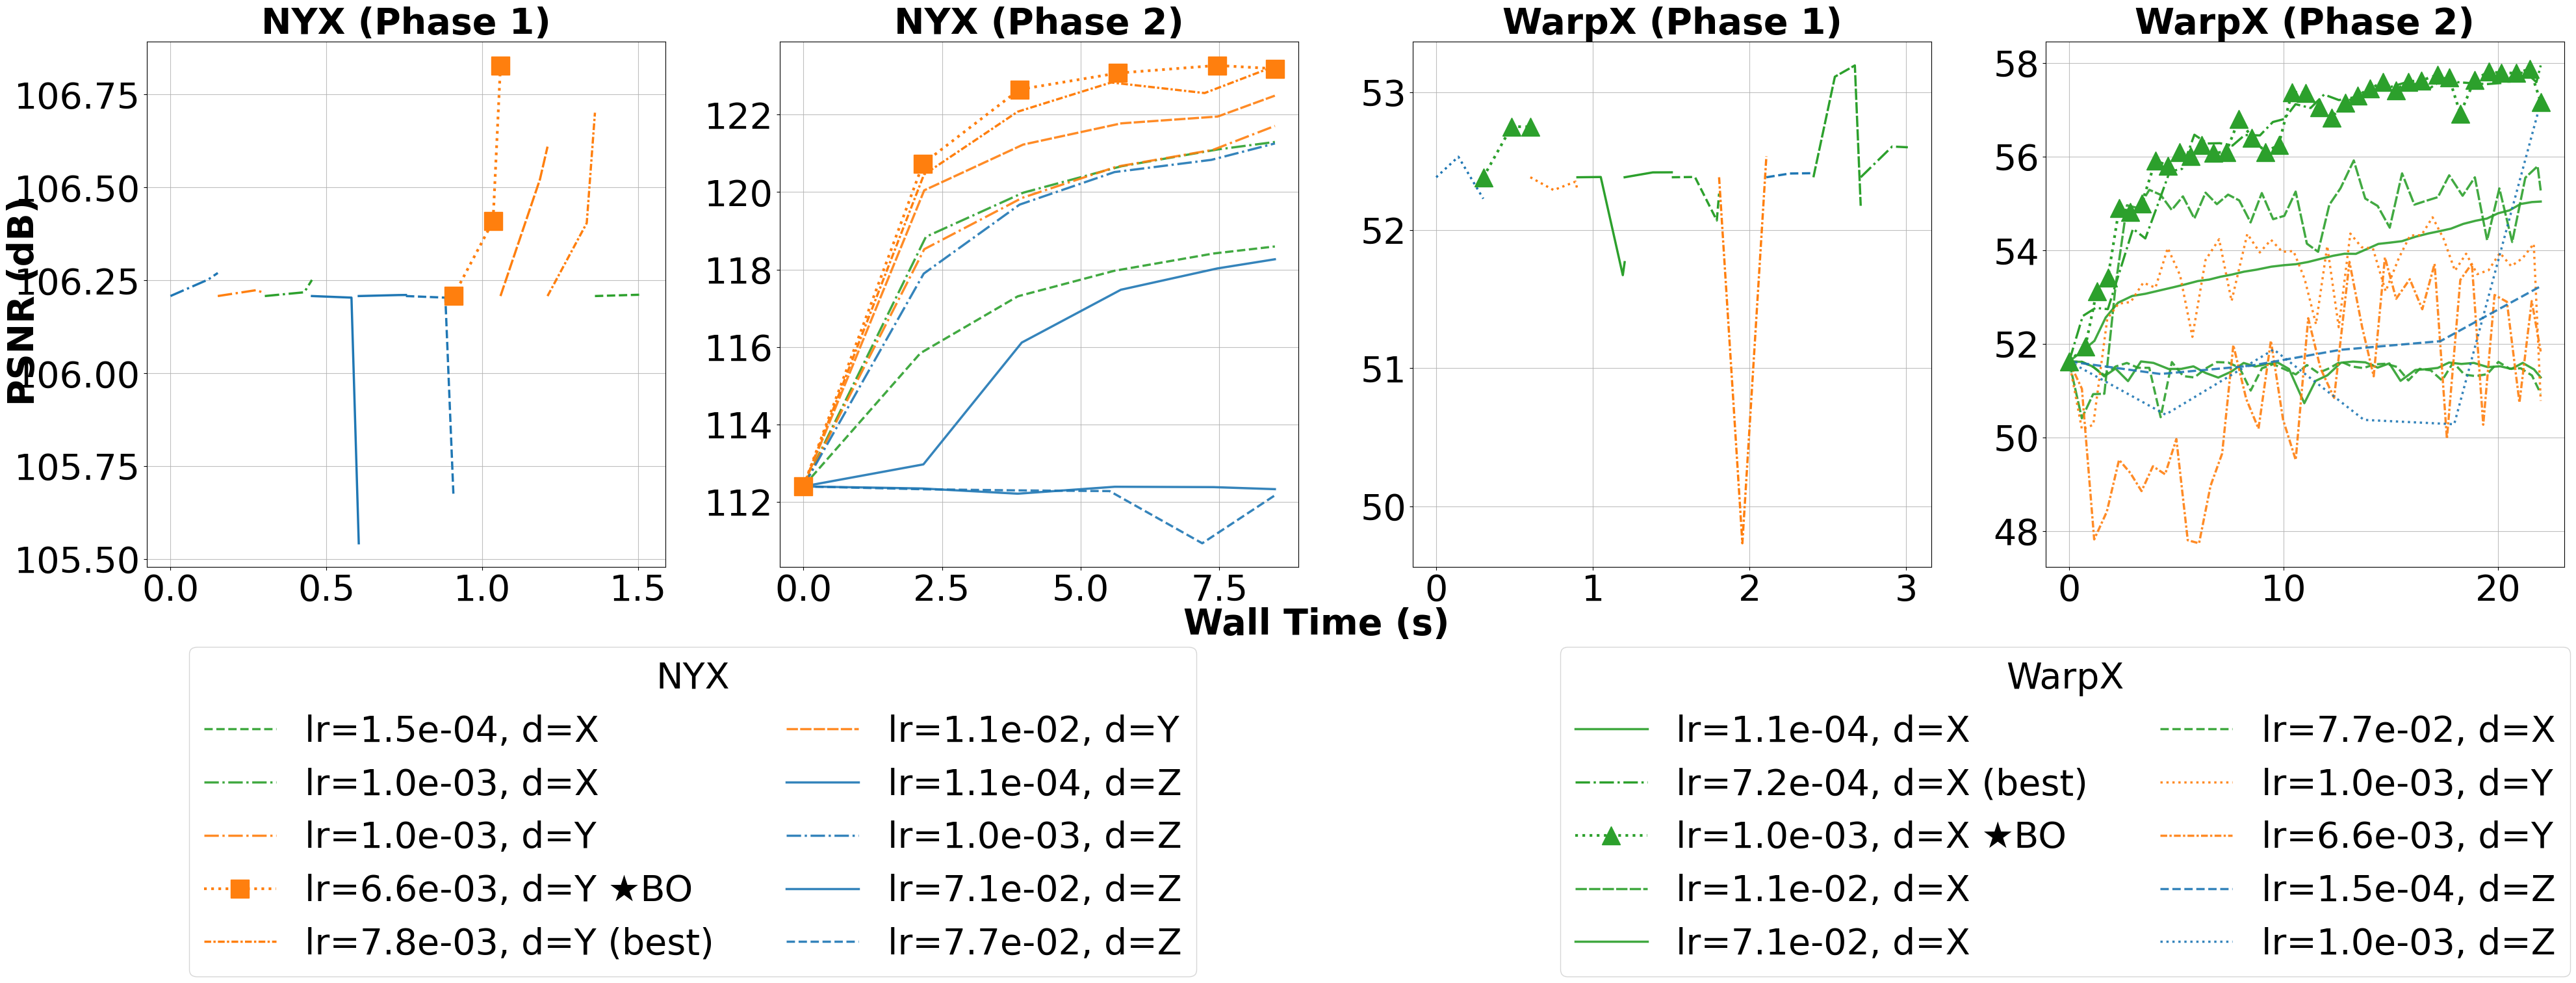

Saved: NYX_WarpX_1x4.pdf


In [7]:
# ── Combined 1x4 figure (紧凑版, 真 1x4) ───────
_LS = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))]

# =============== ✨ 比例参数配置 ✨ ===============
FIG_SIZE = (48, 10.5)         # 画布尺寸 (宽, 高)
WSPACE = 0.22              # 子图横向间距
LEGEND_Y = 0.02            # 图例垂直位置 —— 越大越靠近图
TITLE_FONTSIZE = 40
LABEL_FONTSIZE = 40
TICK_FONTSIZE = 40
LEGEND_FONTSIZE = 40
LEGEND_TITLE_SIZE = 40
MARKER_SIZE = 20
LINE_WIDTH_PICK = 3.0
LINE_WIDTH_NORM = 2.5                                                                                                                                  
# ======================================================

def _psnr_list(hist):
    return [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]

def plot_phase1(ax, R):
    trials  = sorted(R["study_trials"], key=lambda x: x[0])
    all_lrs = sorted({lr for (_, lr, _, _) in trials})
    lr_ls   = {lr: _LS[i % len(_LS)] for i, lr in enumerate(all_lrs)}
    t_offset = 0.0
    for (num, lr_t, d_t, val) in trials:
        hist  = R["all_tune_histories"].get((lr_t, d_t), {})
        t_raw = hist.get("time", [])
        p_raw = _psnr_list(hist)
        if not t_raw or not p_raw:
            t_offset += R["per_trial_cap"]
            continue
        t_abs   = [t_offset + tt for tt in t_raw]
        is_pick = (lr_t == R["best_lr"] and d_t == R["best_direction"])

        ax.plot(t_abs, p_raw, linestyle=lr_ls[lr_t],
                linewidth=LINE_WIDTH_PICK if is_pick else LINE_WIDTH_NORM,
                alpha=1.0 if is_pick else 1,
                color=dir_colors[d_t], zorder=5 if is_pick else 2,
                marker=dir_markers[d_t] if is_pick else None,
                markersize=MARKER_SIZE,
                label=f"lr={lr_t:.1e}, d={d_t}" + (" ★BO" if is_pick else ""))
        t_offset = t_abs[-1]

    ax.grid(True, alpha=0.8)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)

def plot_phase2(ax, R):
    fh      = R["full_histories"]
    all_lrs = sorted({lr for (lr, _) in fh})
    lr_ls   = {lr: _LS[i % len(_LS)] for i, lr in enumerate(all_lrs)}
    fw      = R["final_winner"]
    pick    = (R["best_lr"], R["best_direction"])
    for (lr, d), hist in sorted(fh.items(), key=lambda kv: (kv[0][1], kv[0][0])):
        t_vals = hist.get("time", [])
        p_vals = _psnr_list(hist)
        if not t_vals or not p_vals:
            continue
        is_best = (lr, d) == fw
        is_pick = (lr, d) == pick
        suffix  = (" ★BO" if is_pick else "") + (" (best)" if is_best else "")

        ax.plot(t_vals, p_vals, linestyle=lr_ls[lr], color=dir_colors[d],
                linewidth=LINE_WIDTH_PICK if is_pick else LINE_WIDTH_NORM,
                alpha=1.0 if (is_pick or is_best) else 0.9,
                zorder=5 if is_pick else (4 if is_best else 2),
                marker=dir_markers[d] if is_pick else None,
                markersize=MARKER_SIZE,
                label=f"lr={lr:.1e}, d={d}{suffix}")

    ax.grid(True, alpha=0.8)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)


# ── 画图主体 (真 1x4) ──
fig, axes = plt.subplots(1, 4, figsize=FIG_SIZE,
                         gridspec_kw={'wspace': WSPACE})

plot_phase1(axes[0], result_nyx)
plot_phase2(axes[1], result_nyx)
plot_phase1(axes[2], result_warpx)
plot_phase2(axes[3], result_warpx)

axes[0].set_title("NYX (Phase 1)", fontsize=TITLE_FONTSIZE, fontweight='bold')
axes[1].set_title("NYX (Phase 2)", fontsize=TITLE_FONTSIZE, fontweight='bold')
axes[2].set_title("WarpX (Phase 1)", fontsize=TITLE_FONTSIZE, fontweight='bold')
axes[3].set_title("WarpX (Phase 2)", fontsize=TITLE_FONTSIZE, fontweight='bold')

fig.supxlabel("Wall Time (s)", fontsize=LABEL_FONTSIZE, fontweight='bold', y=0.0)
fig.supylabel("PSNR (dB)", fontsize=LABEL_FONTSIZE, fontweight='bold', x=0.08)

handles_nyx, labels_nyx = axes[1].get_legend_handles_labels()
handles_wpx, labels_wpx = axes[3].get_legend_handles_labels()

fig.legend(handles_nyx, labels_nyx, loc='upper center', bbox_to_anchor=(0.30, LEGEND_Y),
           ncol=2, fontsize=LEGEND_FONTSIZE, title="NYX", title_fontsize=LEGEND_TITLE_SIZE)
fig.legend(handles_wpx, labels_wpx, loc='upper center', bbox_to_anchor=(0.74, LEGEND_Y),
           ncol=2, fontsize=LEGEND_FONTSIZE, title="WarpX", title_fontsize=LEGEND_TITLE_SIZE)

out_png = "NYX_WarpX_1x4.pdf"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")